# Explore DINOv2 features
Sanity-check what the cached frozen features look like. Both variants:

- `cache/dinov2/<scene>/<task>/<exp_id>.npy` — CLS token, shape `(384,)`
- `cache/dinov2_patch4x4/<scene>/<task>/<exp_id>.npy` — pooled patches, `(4, 4, 384)`

Use this to ask: are the features distinguishing per-config? Per-task? Per-scene?

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

In [2]:
REPO = Path('..').resolve()
DATASET = REPO / 'datasets' / 'v10'
CLS_CACHE = REPO / 'cache' / 'dinov2'
PATCH_CACHE = REPO / 'cache' / 'dinov2_patch4x4'

SCENE = 'scene_level2'
TASK = 'clean_nominal'

task_dir = DATASET / SCENE / TASK
manifest = pd.read_csv(task_dir / 'manifest.csv')
print(f'{len(manifest)} configs in {SCENE}/{TASK}')
manifest.head()

241 configs in scene_level2/clean_nominal


,experiment_id,task_id,traj_id,trajectory_file,seed,traj_progress,num_contacts,num_failure_modes,had_any_collision,impacted_geom_ids,pre_qvel_norm,npz_file
0,exp_000250,clean_nominal,0,scene_level2_clean_nominal_00.pkl,20260674,0.0131,47795,6,True,0;86;87;88;89;90;91;92;93;94;95;96,6.7026,exp_000250.npz
1,exp_000251,clean_nominal,0,scene_level2_clean_nominal_00.pkl,20260675,0.1556,52257,6,True,0;65;70;71;72;73;74;75;79;80;81;85;86;87;88;89...,1.4345,exp_000251.npz
2,exp_000252,clean_nominal,0,scene_level2_clean_nominal_00.pkl,20260676,0.0876,48013,6,True,0;65;93;94;95;96,1.9705,exp_000252.npz
3,exp_000253,clean_nominal,0,scene_level2_clean_nominal_00.pkl,20260677,0.0712,48000,6,True,0;93;94;95;96,1.8873,exp_000253.npz
4,exp_000254,clean_nominal,0,scene_level2_clean_nominal_00.pkl,20260678,0.1368,55381,6,True,0;65;70;71;72;73;74;75;78;79;80;81;82;85;86;87...,1.6986,exp_000254.npz


## 1. Inspect one config — image + DINOv2 input + features

In [3]:
row = manifest.iloc[0]
exp_stem = Path(row.npz_file).stem

# Original image
with np.load(task_dir / row.npz_file) as d:
    rgb = np.asarray(d['pre_rgb'])
print('original pre_rgb:', rgb.shape, rgb.dtype)

# Letterbox to 224 (what DINOv2 actually saw)
h, w = rgb.shape[:2]
scale = 224 / max(h, w)
new_h, new_w = int(round(h * scale)), int(round(w * scale))
resized = cv2.resize(rgb, (new_w, new_h), interpolation=cv2.INTER_AREA)
letterbox = np.zeros((224, 224, 3), dtype=np.uint8)
y0, x0 = (224 - new_h) // 2, (224 - new_w) // 2
letterbox[y0:y0 + new_h, x0:x0 + new_w] = resized

# Cached features
cls_feat = np.load(CLS_CACHE / SCENE / TASK / f'{exp_stem}.npy')
patch_feat = np.load(PATCH_CACHE / SCENE / TASK / f'{exp_stem}.npy')
print('cls shape:', cls_feat.shape, '  patch shape:', patch_feat.shape)
print('cls norm:', np.linalg.norm(cls_feat))
print('patch per-cell norms:\n', np.linalg.norm(patch_feat, axis=-1))

original pre_rgb: (480, 640, 3) uint8
cls shape: (384,)   patch shape: (4, 4, 384)
cls norm: 47.180252
patch per-cell norms:
 [[43.86125  43.226368 35.059208 43.3538  ]
 [45.325405 34.327843 31.019346 44.6684  ]
 [45.33203  32.10392  34.79152  38.603115]
 [42.128067 37.233482 37.706974 40.68147 ]]


In [ ]:
for k in d.keys():
    print(k, d[k].shape, d[k].dtype)

KeysView(NpzFile 'object' with keys: pre_rgb, pre_qpos, pre_qvel, pre_ee_pos, pre_gripper_ctrl...)

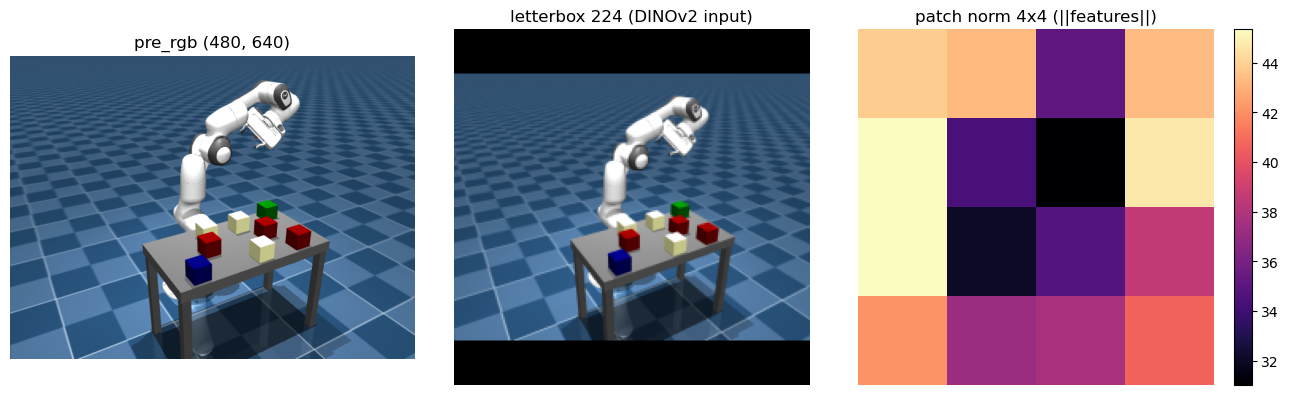

In [4]:
# Side-by-side: original RGB | letterboxed (DINOv2 input) | per-cell patch-norm heatmap
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(rgb);       axes[0].set_title(f'pre_rgb {rgb.shape[:2]}')
axes[1].imshow(letterbox); axes[1].set_title('letterbox 224 (DINOv2 input)')
im = axes[2].imshow(np.linalg.norm(patch_feat, axis=-1), cmap='magma')
axes[2].set_title('patch norm 4x4 (||features||)')
plt.colorbar(im, ax=axes[2], fraction=0.046)
for ax in axes: ax.axis('off')
plt.tight_layout()

## 2. Bulk-load all CLS features for one scene
Walk the cache, build a `(N, 384)` array with `(scene, task, exp_id)` metadata.

In [5]:
def load_scene_cls(cache_root, scene):
    feats, meta = [], []
    scene_dir = cache_root / scene
    for task_dir in sorted(scene_dir.iterdir()):
        if not task_dir.is_dir(): continue
        for npy in sorted(task_dir.glob('*.npy')):
            feats.append(np.load(npy))
            meta.append((scene, task_dir.name, npy.stem))
    feats = np.stack(feats)
    meta = pd.DataFrame(meta, columns=['scene', 'task', 'exp_id'])
    return feats, meta

X, meta = load_scene_cls(CLS_CACHE, SCENE)
print(f'{X.shape[0]} configs, feature dim {X.shape[1]}')
print('per-task counts:'); print(meta.task.value_counts())

2840 configs, feature dim 384
per-task counts:
task
stack_nominal       244
handover_far        243
stack_far           241
clean_nominal       241
clean_far           240
stack_over          238
handover_over       238
sort_far            238
sort_nominal        238
sort_over           229
clean_over          226
handover_nominal    224
Name: count, dtype: int64


## 3. Within-task vs across-task variance — does CLS distinguish configs at all?
If the within-task variance is much smaller than the across-task variance, the CLS feature is essentially a per-task constant — adding it is no better than the existing task one-hot. This is the diagnostic for *why CLS underperformed*.

In [6]:
# Per-feature variance, broken down within-task and across-task means.
task_means = meta.groupby('task').apply(lambda g: X[g.index].mean(axis=0)).values
task_means = np.stack(list(task_means))   # (n_tasks, 384)

global_mean = X.mean(axis=0)
var_total   = X.var(axis=0).mean()
var_between = task_means.var(axis=0).mean()
var_within  = 0.0
for t, idx in meta.groupby('task').groups.items():
    var_within += X[idx].var(axis=0).mean() * (len(idx) / len(X))

print(f'  total variance     {var_total:.4f}')
print(f'  between-task var   {var_between:.4f}  ({var_between/var_total*100:.0f}%)')
print(f'  within-task var    {var_within:.4f}  ({var_within/var_total*100:.0f}%)')
print(f'  ratio between/within: {var_between/var_within:.2f}')

  total variance     0.8077
  between-task var   0.0462  (6%)
  within-task var    0.7618  (94%)
  ratio between/within: 0.06


/tmp/ipykernel_318597/1788543100.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  task_means = meta.groupby('task').apply(lambda g: X[g.index].mean(axis=0)).values


Interpretation: if `between/within > ~3`, the CLS feature is mostly task-id information and adds little beyond the task one-hot already in the input.

## 4. PCA of CLS features — do they cluster by task?

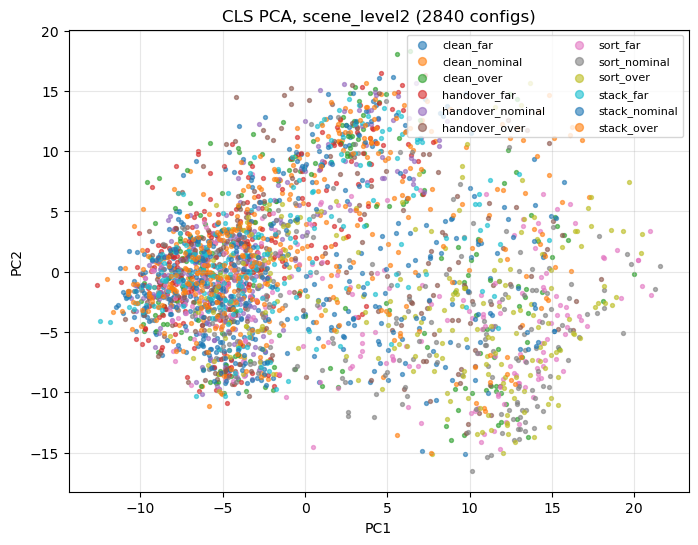

In [7]:
from sklearn.decomposition import PCA
Z = PCA(n_components=2).fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 6))
for task in sorted(meta.task.unique()):
    idx = meta.task == task
    ax.scatter(Z[idx, 0], Z[idx, 1], s=8, alpha=0.6, label=task)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'CLS PCA, {SCENE} ({len(X)} configs)')
ax.legend(fontsize=8, markerscale=2, ncol=2)
ax.grid(alpha=0.3)

## 5. Nearest-neighbour sanity check
Pick a query config; find its 5 nearest neighbours in CLS space; show their images.

Good DINOv2 features → neighbours look visually similar AND share task / config patterns. Useless features → neighbours look random.

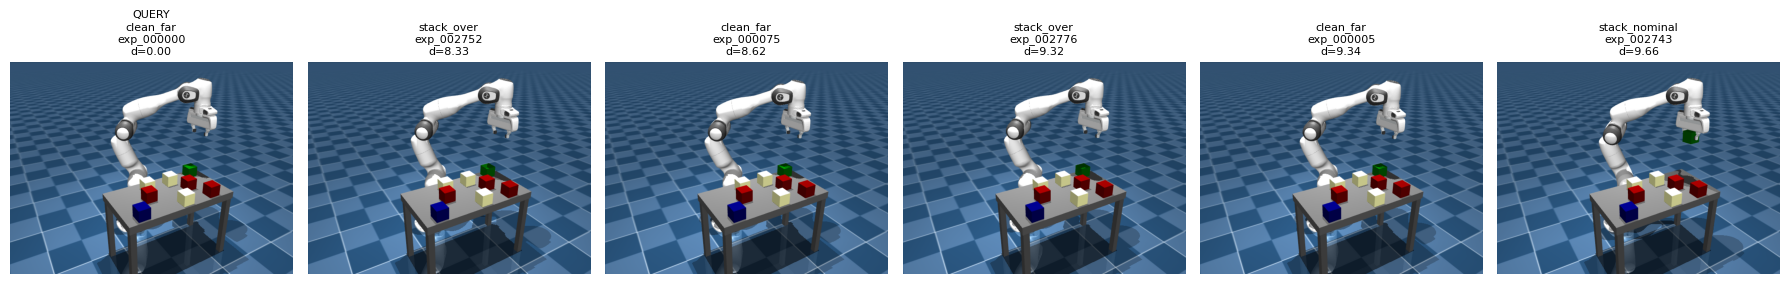

In [8]:
from scipy.spatial.distance import cdist

Q_INDEX = 0   # change to inspect different queries
K = 5
dists = cdist(X[Q_INDEX:Q_INDEX+1], X)[0]
nn_idx = np.argsort(dists)[:K + 1]   # query itself first

fig, axes = plt.subplots(1, K + 1, figsize=(3 * (K + 1), 3))
for ax_i, mi in enumerate(nn_idx):
    row = meta.iloc[mi]
    npz = DATASET / row.scene / row.task / f'{row.exp_id}.npz'
    with np.load(npz) as d:
        img = np.asarray(d['pre_rgb'])
    axes[ax_i].imshow(img)
    axes[ax_i].set_title(f'{row.task}\n{row.exp_id}\nd={dists[mi]:.2f}', fontsize=8)
    axes[ax_i].axis('off')
axes[0].set_title('QUERY\n' + axes[0].get_title(), fontsize=8)
plt.tight_layout()

## 6. Patch features — PCA on the per-cell descriptors
Each config has a (4, 4, 384) patch grid. Flatten across configs to (N*16, 384), PCA each cell to 3 colour channels, render the per-config 4×4 grid as a small RGB "feature map."

This is a quick visual probe for *what the patches encode* — if they're meaningful, you'll see consistent per-region colours that change with config.

patches shape: (1000, 4, 4, 384)


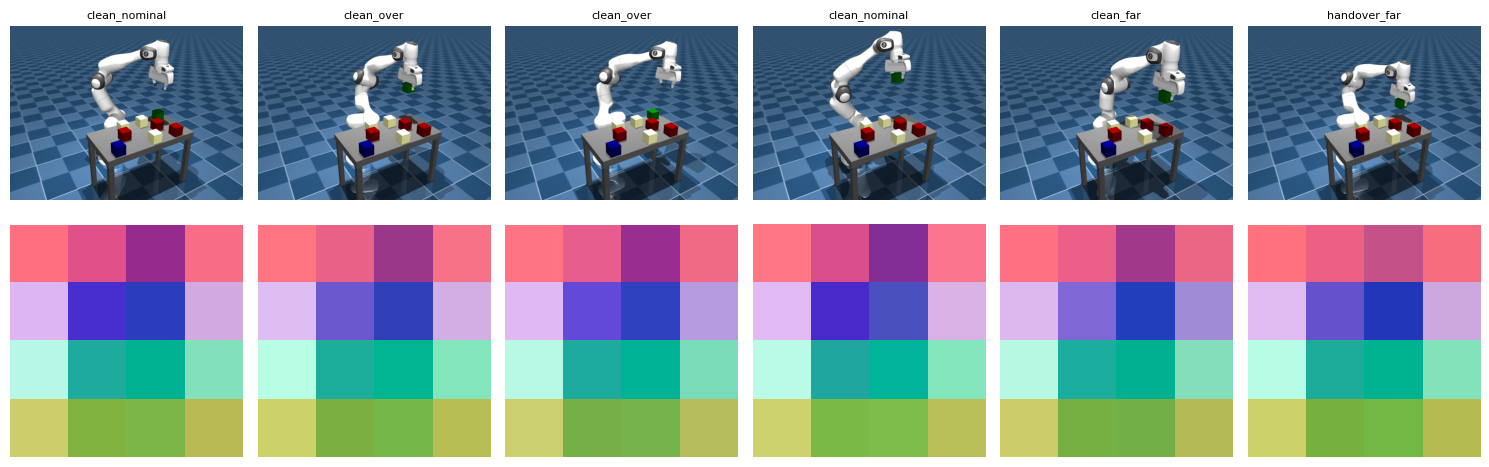

In [9]:
def load_scene_patches(cache_root, scene, max_n=1000):
    feats, meta = [], []
    scene_dir = cache_root / scene
    for task_dir in sorted(scene_dir.iterdir()):
        if not task_dir.is_dir(): continue
        for npy in sorted(task_dir.glob('*.npy')):
            if len(feats) >= max_n: break
            feats.append(np.load(npy))
            meta.append((scene, task_dir.name, npy.stem))
    return np.stack(feats), pd.DataFrame(meta, columns=['scene', 'task', 'exp_id'])

P, pmeta = load_scene_patches(PATCH_CACHE, SCENE, max_n=1000)
print('patches shape:', P.shape)   # (N, 4, 4, 384)

flat = P.reshape(-1, 384)
pca3 = PCA(n_components=3).fit(flat)

def patch_to_rgb(patch_grid):
    flat = patch_grid.reshape(-1, 384)
    rgb = pca3.transform(flat).reshape(4, 4, 3)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)
    return rgb

# Show 6 random configs: image | patch RGB
rng = np.random.default_rng(0)
sel = rng.choice(len(P), size=6, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for c, mi in enumerate(sel):
    row = pmeta.iloc[mi]
    with np.load(DATASET / row.scene / row.task / f'{row.exp_id}.npz') as d:
        img = np.asarray(d['pre_rgb'])
    axes[0, c].imshow(img); axes[0, c].axis('off')
    axes[0, c].set_title(row.task, fontsize=8)
    axes[1, c].imshow(patch_to_rgb(P[mi]), interpolation='nearest')
    axes[1, c].axis('off')
plt.tight_layout()

## 7. Cross-scene comparison — is the level2 patch win unique?

After R3-patch beat R1+vision on `scene_level2` (-76% vs -73% MSE) but
not anywhere else, the question was: *is that level2-specific*?
Possible reading: level2's tiny table (~0.7x0.43 m vs the others at
~1.3 m wide) fits better in `front_cam` -- DINOv2 sees more
workspace per pixel there.

Diagnostics below: same variance + PCA tests, run across all 5 scenes.

In [ ]:
SCENES = ['scene_level2', 'scene_kitchen', 'scene_workshop',
          'scene_grocery', 'scene_cluttered']

def variance_breakdown(X, meta, group_col='task'):
    """Total / between-group / within-group / ratio for any grouping."""
    var_total = X.var(axis=0).mean()
    means = np.stack([X[idx].mean(axis=0)
                      for _, idx in meta.groupby(group_col).groups.items()])
    var_between = means.var(axis=0).mean()
    var_within = sum(
        X[idx].var(axis=0).mean() * (len(idx) / len(X))
        for _, idx in meta.groupby(group_col).groups.items()
    )
    return var_total, var_between, var_within, var_between / max(var_within, 1e-9)

# CLS variance breakdown per scene
rows = []
for s in SCENES:
    X_s, m_s = load_scene_cls(CLS_CACHE, s)
    vt, vb, vw, ratio = variance_breakdown(X_s, m_s, 'task')
    rows.append({'scene': s, 'n_configs': len(X_s),
                 'var_total': vt, 'var_between_task': vb,
                 'var_within_task': vw, 'between/within': ratio})
pd.DataFrame(rows).round(4)

**Reading**: `between/within` is the ratio of between-task to within-task feature variance.

- High ratio (>3) -> CLS is mostly a task-id pointer, adds little beyond `task_one_hot`.
- Low ratio (<1) -> CLS varies as much within a task as between tasks; should carry per-config information.
- Different ratios across scenes -> DINOv2 sees scenes with different amounts of structure.

## 8. Cross-scene CLS PCA -- do scenes separate cleanly?

If we PCA all 16k CLS features together and colour by scene, we should see 5 clusters.
That tells us *most* of DINOv2's variance is "which scene am I in" -- i.e. useful for
multi-scene routing but redundant with `scene_one_hot` already in our input.

In [ ]:
# Bulk-load CLS for all scenes (slow ~30s)
all_X, all_meta = [], []
for s in SCENES:
    X_s, m_s = load_scene_cls(CLS_CACHE, s)
    all_X.append(X_s); all_meta.append(m_s)
all_X = np.vstack(all_X)
all_meta = pd.concat(all_meta, ignore_index=True)
print(f'loaded {len(all_X)} configs across {all_meta.scene.nunique()} scenes')

Z = PCA(n_components=2).fit_transform(all_X)

fig, ax = plt.subplots(figsize=(8, 6))
for s in SCENES:
    idx = all_meta.scene == s
    ax.scatter(Z[idx, 0], Z[idx, 1], s=4, alpha=0.5, label=s.replace('scene_', ''))
ax.set_title(f'CLS PCA across {len(all_X)} configs - colour=scene')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=9, markerscale=3); ax.grid(alpha=0.3)

## 9. Per-scene patch *spatial variance* -- the level2 hypothesis test

If level2 wins with patches because the table fills the camera frame more, we'd
expect *more variation across the 4x4 patch grid* in level2 than in scenes where
the table is smaller relative to the frame. Per-config patch grid variance,
averaged across configs, should be **higher for level2**.

In [ ]:
import time

results = []
for s in SCENES:
    t0 = time.time()
    P, pm = load_scene_patches(PATCH_CACHE, s, max_n=300)   # 300 per scene; fast
    # P is (N, 4, 4, 384). For each config: variance over the 16 patch cells
    # for each channel, mean over channels. Higher = more spatially distinct patches.
    flat = P.reshape(P.shape[0], 16, 384)
    spatial_var_per_cfg = flat.var(axis=1).mean(axis=1)   # (N,)
    results.append({
        'scene': s,
        'n': len(P),
        'spatial_var_mean': float(spatial_var_per_cfg.mean()),
        'spatial_var_std':  float(spatial_var_per_cfg.std()),
        'load_time_s':      round(time.time() - t0, 1),
    })
pd.DataFrame(results).round(4)

**Reading**:
- If `spatial_var_mean` is much higher for `scene_level2` than the others, the level2
  patch win likely is "table fills the frame, patches are richer."
- If it is roughly equal across scenes, the level2 win is for some *other* reason --
  maybe the obstacle layout itself (smaller, denser obstacles play better with
  patch-grid-driven local features).

Either way, this number is the cleanest single-statistic test of the level2 hypothesis.

In [ ]:
# Visual: per-cell patch norm for one config from each scene, side-by-side.
# Brighter cells = more activated. We can see if level2's grid looks more
# texturally varied than the others.
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for c, s in enumerate(SCENES):
    P_s, pm_s = load_scene_patches(PATCH_CACHE, s, max_n=1)
    row = pm_s.iloc[0]
    with np.load(DATASET / row.scene / row.task / f'{row.exp_id}.npz') as d:
        img = np.asarray(d['pre_rgb'])
    axes[0, c].imshow(img); axes[0, c].axis('off')
    axes[0, c].set_title(s.replace('scene_', ''), fontsize=10)
    pn = np.linalg.norm(P_s[0], axis=-1)
    axes[1, c].imshow(pn, cmap='magma', interpolation='nearest')
    axes[1, c].axis('off')
    axes[1, c].set_title(f'patch ||f|| var={pn.var():.2f}', fontsize=9)
plt.tight_layout()

## 10. Pick your own line of inquiry
Things you might extend below:
- Repeat the variance diagnostic on patches (per-cell): are some grid cells more discriminative than others?
- Compare CLS distributions across scenes (load all 5 scenes, scene-coloured PCA).
- Ablate: what if we average each config's 4×4 patches into a single 384-dim vec — does it match CLS or beat it?
- Cosine similarity heatmaps of patch features within a single config (do diagonal patches encode spatial proximity?).